# 07_Sistema_Industrial · Pipeline de Monitorización por Capas

**Objetivo**: implementar el sistema de monitorización industrial que integra los tres
datasets del proyecto en una arquitectura de escalada por capas, tal como funcionan
los sistemas reales de mantenimiento predictivo.

---

## Arquitectura del sistema

```
┌─────────────────────────────────────────────────────────────────────┐
│  CAPA 1 — Detección eléctrica          [siempre activa, 1 min]      │
│  Fuente: sensores externos (pinzas amperimétricas)                  │
│  Dataset: SPARK · Señales: P_total, I1/I2/I3, THD, PF              │
│  Modelo: umbral estadístico sobre anomaly_score (Isolation Forest)  │
├─────────────────────────────────────────────────────────────────────┤
│  CAPA 2 — Confirmación mecánica        [se activa si Capa 1 alerta] │
│  Fuente: controlador CNC (OPC-UA / MTConnect) — sin hardware extra  │
│                                                                     │
│  PROTOTIPO  → Dataset KIT (500 Hz, sensores externos): RF + LOO-CV │
│  PRODUCCIÓN → Dataset CNC Mill (señales internas): RF reentrenable │
│                                                                     │
│  El modelo arranca con el baseline KIT y se sustituye en planta por │
│  el modelo CNC, que se reentrena de forma incremental con datos     │
│  reales. Los 18 experimentos CNC actúan como cold-start.           │
├─────────────────────────────────────────────────────────────────────┤
│  CAPA 3 — Clasificación de fallo    [se activa si Capa 2 confirma] │
│  Fuente: MES / SCADA (parámetros de proceso)                        │
│  Dataset: AI4I · Señales: velocidad, torque, desgaste, temperatura  │
│  Modelo: StackingClassifier (LightGBM + RF) — modelo de producción  │
└─────────────────────────────────────────────────────────────────────┘
```

**Principio de diseño industrial**: el sistema es útil aunque solo exista la Capa 1.
Cada capa adicional aumenta la confianza y el detalle del diagnóstico.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle, os, glob, warnings
warnings.filterwarnings('ignore')

PROC_DIR   = os.path.join('..', 'data', 'processed')
MODELS_DIR = os.path.join('..', 'models')

# ── Tipos de fallo AI4I ──────────────────────────────────────────────────────
FAULT_NAMES = {
    0: 'Sin fallo',
    1: 'TWF — Desgaste herramienta',
    2: 'HDF — Fallo disipación calor',
    3: 'PWF — Fallo de potencia',
    4: 'OSF — Sobreesfuerzo',
    5: 'RNF — Fallo aleatorio',
}

# ── Acciones recomendadas por tipo ──────────────────────────────────────────
ACTIONS = {
    0:  ('NORMAL',      '#2ecc71', 'Operación nominal. Continuar.'),
    1:  ('PROGRAMAR',   '#f39c12', 'Cambio de herramienta en próxima parada.'),
    2:  ('REVISAR',     '#e67e22', 'Revisar sistema de refrigeración.'),
    3:  ('ATENCIÓN',    '#e74c3c', 'Potencia fuera de rango. Revisar motor.'),
    4:  ('PARAR',       '#c0392b', 'Sobreesfuerzo crítico. PARAR MÁQUINA.'),
    5:  ('INSPECCIÓN',  '#9b59b6', 'Fallo aleatorio detectado. Inspección manual.'),
    99: ('ALERTA ELEC.','#e67e22', 'Anomalía eléctrica. Verificar red y conexiones.'),
    88: ('ALERTA MECA.','#e74c3c', 'Fallo mecánico confirmado. Revisar husillo/ejes.'),
}

print('Sistema de Monitorización Industrial — cargando componentes...')

Sistema de Monitorización Industrial — cargando componentes...


## 1. Capa 1 — Modelo de detección eléctrica

Cargamos los datos SPARK scored (resultados del Isolation Forest por máquina)
para establecer el umbral de anomalía eléctrica.

En Isolation Forest, `anomaly_score < 0` indica anomalía. Usamos el percentil 5
de los scores normales como umbral para reducir falsas alarmas.

In [13]:
# ── Cargar estadísticas de scores SPARK por máquina ─────────────────────────
spark_stats = {}

for fpath in sorted(glob.glob(os.path.join(PROC_DIR, 'spark_TEC_*_scored.parquet'))):
    df = pd.read_parquet(fpath)
    machine = df['machine'].iloc[0]
    scores  = df['anomaly_score'].dropna().values

    # Referencia: distribución de scores en operación normal
    # (en ausencia de etiquetas reales, usamos todos los datos)
    spark_stats[machine] = {
        'score_mean':   scores.mean(),
        'score_std':    scores.std(),
        'threshold':    np.percentile(scores, 5),  # 5% más bajo = umbral anomalía
        'n_readings':   len(scores),
    }

df_stats = pd.DataFrame(spark_stats).T.round(4)
print('Estadísticas SPARK por máquina:')
print(df_stats.to_string())

# Umbral global (media de umbrales por máquina)
THRESHOLD_L1 = df_stats['threshold'].mean()
print(f'\nUmbral Layer 1 (global): {THRESHOLD_L1:.4f}')
print('Interpretación: anomaly_score < umbral → alerta eléctrica')

Estadísticas SPARK por máquina:
               score_mean  score_std  threshold  n_readings
TEC_48S            0.2411     0.0912        0.0    501785.0
TEC_CFST161        0.1485     0.0834       -0.0    501785.0
TEC_CTX800TC       0.2372     0.0995        0.0    501788.0
TEC_Chiron800      0.2163     0.0947       -0.0    501784.0
TEC_DMF3008        0.2215     0.0960        0.0    501783.0
TEC_DMU125MB       0.2001     0.0899        0.0    501781.0
TEC_DNG50evo       0.2051     0.0908       -0.0    501788.0
TEC_E110           0.2237     0.0963        0.0    501781.0
TEC_E30D2          0.1696     0.0898        0.0    501786.0
TEC_JWA24          0.1698     0.0823        0.0    501787.0
TEC_MV2400R        0.2004     0.0845        0.0    501787.0

Umbral Layer 1 (global): 0.0000
Interpretación: anomaly_score < umbral → alerta eléctrica


## 2. Capa 2 — Modelo de confirmación mecánica (prototipo: KIT)

En esta demo usamos el dataset KIT como baseline de Capa 2.
En producción este modelo se sustituye por el entrenado con señales CNC internas
(ver `05_02_Tool_Tracking_CNC.ipynb`), que no necesita sensores externos y puede
reentrenarse de forma incremental con datos reales de planta.

Las features clave del modelo KIT son del husillo (eje 6): TORQUE, POWER, CURRENT, LOAD.
El equivalente en CNC serían los registros de corriente de eje, carga del husillo y
error de seguimiento de posición accesibles directamente por OPC-UA.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import f1_score, roc_auc_score

# Cargar features KIT
kit_path = os.path.join(PROC_DIR, 'industrial_features_v2.csv')
if not os.path.exists(kit_path):
    kit_path = os.path.join(PROC_DIR, 'industrial_features.csv')
    print(f'Usando features básicas KIT (ejecuta 02_03 para features enriquecidas)')
else:
    print('Usando features enriquecidas KIT v2')

kit_df   = pd.read_csv(kit_path)
kit_meta = ['trial','anomaly','comment','fault_type','fault_name','n_samples']
feat_kit = [c for c in kit_df.columns if c not in kit_meta]

X_kit    = kit_df[feat_kit].fillna(0).values
y_kit    = kit_df['anomaly'].values
scaler_kit = StandardScaler()
X_kit_sc   = scaler_kit.fit_transform(X_kit)

# Entrenar modelo final (sobre todos los datos para despliegue)
rf_kit = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_kit.fit(X_kit_sc, y_kit)

# Validación LOO-CV
loo  = LeaveOneOut()
yp   = cross_val_predict(rf_kit, X_kit_sc, y_kit, cv=loo)
ypr  = cross_val_predict(rf_kit, X_kit_sc, y_kit, cv=loo, method='predict_proba')[:,1]

f1  = f1_score(y_kit, yp)
auc = roc_auc_score(y_kit, ypr)
print(f'Layer 2 (KIT Random Forest) — F1={f1:.3f} | AUC={auc:.3f} | LOO-CV')
THRESHOLD_L2 = 0.45  # umbral de probabilidad para confirmación mecánica

Usando features enriquecidas KIT v2
Layer 2 (KIT Random Forest) — F1=0.645 | AUC=0.761 | LOO-CV


## 3. Capa 3 — Modelo de clasificación de fallo

Cargamos el modelo de producción: **StackingClassifier (LightGBM + RF)**
entrenado sobre AI4I 2020 con umbral optimizado (F1=0.892, AUC=0.980).

Este modelo clasifica el **tipo** de fallo cuando las capas anteriores ya lo
han confirmado — es la capa que genera la orden de mantenimiento específica.

In [15]:
# Cargar modelo de producción AI4I
with open(os.path.join(MODELS_DIR, 'final_model.pkl'), 'rb') as f:
    bundle = pickle.load(f)

model_ai4i    = bundle['model']
threshold_ai4i = bundle['threshold']
scaler_ai4i   = bundle['scaler']

# Features esperadas por el modelo AI4I
AI4I_FEATURES = ['type_enc','air_temp','proc_temp','rot_speed',
                  'torque','tool_wear','power','temp_diff','wear_torque','wear_ratio']

TWF_MIN = {'L': 200, 'M': 220, 'H': 240}

def prepare_ai4i_features(params):
    """Transforma parámetros de proceso en el vector de 10 features del modelo."""
    type_map = {'L':0, 'M':1, 'H':2}
    te  = type_map.get(params['type'], 1)
    pwr = params['torque'] * params['rot_speed'] * 2 * np.pi / 60
    return np.array([[
        te,
        params['air_temp'],
        params['proc_temp'],
        params['rot_speed'],
        params['torque'],
        params['tool_wear'],
        pwr,
        params['proc_temp'] - params['air_temp'],
        params['tool_wear'] * params['torque'],
        params['tool_wear'] / TWF_MIN[params['type']],
    ]])

print(f'Layer 3 (AI4I StackingClassifier) cargado.')
print(f'Umbral producción: {threshold_ai4i:.4f} | F1=0.913 | AUC=0.975')

Layer 3 (AI4I StackingClassifier) cargado.
Umbral producción: 0.9863 | F1=0.913 | AUC=0.975


## 4. EscalationPipeline — La lógica de escalada

Implementamos la clase central del sistema. Su método `monitor()` recibe
un diccionario con las señales disponibles y devuelve un `AlarmResult`
con el nivel de alarma, la causa y la acción recomendada.

**Lógica de decisión:**
```
anomaly_score < umbral_L1?
    NO  → Normal, no escalar
    SÍ  → ¿Datos mecánicos disponibles?
              NO  → Alarma Capa 1 (anomalía eléctrica)
              SÍ  → P(mecánico) > umbral_L2?
                        NO  → Problema eléctrico aislado (no mecánico)
                        SÍ  → ¿Datos de proceso disponibles?
                                  NO  → Alarma Capa 2 (fallo mecánico)
                                  SÍ  → Clasificar tipo + Alarma Capa 3
```

In [16]:
from dataclasses import dataclass, field
from typing import Optional, Dict, Any

@dataclass
class AlarmResult:
    layers_activated: int         # cuántas capas se activaron (0-3)
    alarm: bool                   # ¿hay alarma?
    fault_code: int               # 0=normal, 99=eléctrico, 88=mecánico, 1-5=AI4I
    probability: float            # probabilidad de fallo (0-1)
    score_l1: Optional[float]     # anomaly_score eléctrico
    prob_l2: Optional[float]      # P(anomalía) mecánica
    prob_l3: Optional[float]      # P(fallo) proceso
    details: Dict[str, Any] = field(default_factory=dict)

    @property
    def action_label(self):  return ACTIONS.get(self.fault_code, ACTIONS[0])[0]
    @property
    def action_color(self):  return ACTIONS.get(self.fault_code, ACTIONS[0])[1]
    @property
    def action_text(self):   return ACTIONS.get(self.fault_code, ACTIONS[0])[2]
    @property
    def fault_name(self):    return FAULT_NAMES.get(self.fault_code,
                                   {99:'Anomalía eléctrica', 88:'Fallo mecánico'}.get(
                                       self.fault_code, 'Desconocido'))


class EscalationPipeline:
    """
    Pipeline de monitorización industrial en 3 capas.

    Parámetros de monitor():
      signals = {
        'electrical': {'anomaly_score': float},          # Capa 1 — SPARK
        'mechanical': array of shape (1, n_kit_features), # Capa 2 — KIT
        'process':    dict con keys type/air_temp/etc.,  # Capa 3 — AI4I
      }
    """

    def __init__(self, threshold_l1, rf_kit, scaler_kit, threshold_l2,
                 model_ai4i, scaler_ai4i, threshold_ai4i):
        self.thr1        = threshold_l1
        self.rf_kit      = rf_kit
        self.sc_kit      = scaler_kit
        self.thr2        = threshold_l2
        self.model_ai4i  = model_ai4i
        self.sc_ai4i     = scaler_ai4i
        self.thr3        = threshold_ai4i

    def monitor(self, signals: dict) -> AlarmResult:
        score_l1 = prob_l2 = prob_l3 = None

        # ── CAPA 1: detección eléctrica ──────────────────────────────────────
        elec = signals.get('electrical')
        if elec is None:
            return AlarmResult(0, False, 0, 0.0, None, None, None,
                               {'msg': 'Sin datos eléctricos'})

        score_l1 = elec['anomaly_score']

        if score_l1 >= self.thr1:            # score normal → sin alarma
            return AlarmResult(1, False, 0, 0.0, score_l1, None, None,
                               {'msg': 'Operación eléctrica normal'})

        # ── CAPA 2: confirmación mecánica ────────────────────────────────────
        mech = signals.get('mechanical')
        if mech is None:
            return AlarmResult(1, True, 99, 0.5, score_l1, None, None,
                               {'msg': 'Anomalía eléctrica. Sin datos mecánicos.'})

        X_m    = self.sc_kit.transform(np.array(mech).reshape(1, -1))
        prob_l2 = self.rf_kit.predict_proba(X_m)[0, 1]

        if prob_l2 < self.thr2:
            return AlarmResult(2, True, 99, prob_l2, score_l1, prob_l2, None,
                               {'msg': 'Anomalía eléctrica. Mecánica normal → revisar red.'})

        # ── CAPA 3: clasificación de fallo ───────────────────────────────────
        proc = signals.get('process')
        if proc is None:
            return AlarmResult(2, True, 88, prob_l2, score_l1, prob_l2, None,
                               {'msg': 'Fallo mecánico confirmado. Sin datos de proceso.'})

        feat_ai4i = prepare_ai4i_features(proc)
        feat_sc   = self.sc_ai4i.transform(feat_ai4i)
        prob_l3   = self.model_ai4i.predict_proba(feat_sc)[0, 1]

        # Clasificar tipo de fallo (umbral conservador porque ya tenemos confirmación)
        fault_code = 0
        if prob_l3 >= self.thr3:
            # Heurísticas basadas en parámetros de proceso (replicando lógica AI4I)
            tw   = proc['tool_wear']
            tq   = proc['torque']
            pwr  = tq * proc['rot_speed'] * 2 * np.pi / 60
            tdiff = proc['proc_temp'] - proc['air_temp']
            twf_min = TWF_MIN[proc['type']]

            if tw >= twf_min * 0.85 and tq > 55:
                fault_code = 1  # TWF
            elif tdiff < 8.6 and proc['rot_speed'] < 1380:
                fault_code = 2  # HDF
            elif not (3500 <= pwr <= 9000):
                fault_code = 3  # PWF
            elif tw * tq > 11000:
                fault_code = 4  # OSF
            else:
                fault_code = 5  # RNF

        return AlarmResult(3, prob_l3 >= self.thr3, fault_code,
                           prob_l3, score_l1, prob_l2, prob_l3,
                           {'msg': f'Clasificación completa. P(fallo)={prob_l3:.3f}'})


# Instanciar pipeline
pipeline = EscalationPipeline(
    threshold_l1   = THRESHOLD_L1,
    rf_kit         = rf_kit,
    scaler_kit     = scaler_kit,
    threshold_l2   = THRESHOLD_L2,
    model_ai4i     = model_ai4i,
    scaler_ai4i    = scaler_ai4i,
    threshold_ai4i = threshold_ai4i,
)
print('EscalationPipeline instanciado correctamente.')

EscalationPipeline instanciado correctamente.


## 5. Simulación — 4 escenarios industriales reales

Simulamos los 4 situaciones más habituales en una planta de mecanizado:

| Escenario | Descripción | Señales disponibles |
|---|---|---|
| **A** | Operación normal | Capa 1 + 2 + 3 |
| **B** | Anomalía eléctrica aislada (problema de red) | Capa 1 + 2 + 3 |
| **C** | Fallo en cascada — desgaste crítico inminente | Capa 1 + 2 + 3 |
| **D** | Solo sensores eléctricos disponibles (máquina legacy) | Solo Capa 1 |

Los valores de señal están basados en los rangos reales de los tres datasets.

> **Nota**: los vectores mecánicos de los escenarios se calculan con estadísticos del dataset KIT. En producción vendrían de lecturas en vivo del controlador CNC, no del dataset de entrenamiento.

In [17]:
# ── Definición de los 4 escenarios ──────────────────────────────────────────

# NOTA: en produccion estos valores vendrian de senales en vivo del CNC.
# Valores KIT normales (media de experimentos normales del dataset)
kit_normal_vals = kit_df[kit_df['anomaly']==0][feat_kit].fillna(0).mean().values
kit_anomaly_vals = kit_df[kit_df['anomaly']==1][feat_kit].fillna(0).mean().values

scenarios = {

    'A — Operación normal': {
        'electrical': {'anomaly_score': 0.12},
        'mechanical': kit_normal_vals,
        'process': {
            'type': 'M', 'air_temp': 300.1, 'proc_temp': 309.8,
            'rot_speed': 1650, 'torque': 38.5, 'tool_wear': 55,
        },
    },

    'B — Anomalía eléctrica (red)': {
        'electrical': {'anomaly_score': -0.14},   # Anomalía eléctrica
        'mechanical': kit_normal_vals,             # Mecánica normal
        'process': {
            'type': 'M', 'air_temp': 300.0, 'proc_temp': 310.1,
            'rot_speed': 1700, 'torque': 40.0, 'tool_wear': 80,
        },
    },

    'C — Fallo en cascada (desgaste crítico)': {
        'electrical': {'anomaly_score': -0.19},   # Anomalía eléctrica
        'mechanical': kit_anomaly_vals,            # Anomalía mecánica
        'process': {
            'type': 'M', 'air_temp': 298.5, 'proc_temp': 310.5,
            'rot_speed': 1380, 'torque': 68.0, 'tool_wear': 225,
        },
    },

    'D — Solo Capa 1 disponible (máquina legacy)': {
        'electrical': {'anomaly_score': -0.09},   # Anomalía eléctrica
        'mechanical': None,                        # Sin datos CNC
        'process':    None,                        # Sin datos MES
    },
}

# Ejecutar pipeline sobre cada escenario
results = {}
for name, signals in scenarios.items():
    results[name] = pipeline.monitor(signals)
    r = results[name]
    print(f'\n{name}')
    print(f'  Capas activadas : {r.layers_activated}')
    print(f'  Alarma          : {r.alarm}')
    print(f'  Tipo fallo      : {r.fault_name}')
    print(f'  Acción          : [{r.action_label}] {r.action_text}')
    print(f'  Score L1        : {r.score_l1}')
    print(f'  P(mecánico) L2  : {r.prob_l2}')
    print(f'  P(fallo) L3     : {r.prob_l3}')


A — Operación normal
  Capas activadas : 1
  Alarma          : False
  Tipo fallo      : Sin fallo
  Acción          : [NORMAL] Operación nominal. Continuar.
  Score L1        : 0.12
  P(mecánico) L2  : None
  P(fallo) L3     : None

B — Anomalía eléctrica (red)
  Capas activadas : 2
  Alarma          : True
  Tipo fallo      : Anomalía eléctrica
  Acción          : [ALERTA ELEC.] Anomalía eléctrica. Verificar red y conexiones.
  Score L1        : -0.14
  P(mecánico) L2  : 0.35
  P(fallo) L3     : None

C — Fallo en cascada (desgaste crítico)
  Capas activadas : 3
  Alarma          : True
  Tipo fallo      : TWF — Desgaste herramienta
  Acción          : [PROGRAMAR] Cambio de herramienta en próxima parada.
  Score L1        : -0.19
  P(mecánico) L2  : 0.708
  P(fallo) L3     : 0.9995043251054222

D — Solo Capa 1 disponible (máquina legacy)
  Capas activadas : 1
  Alarma          : True
  Tipo fallo      : Anomalía eléctrica
  Acción          : [ALERTA ELEC.] Anomalía eléctrica. Verifi

## 6. Dashboard del operario

Visualizamos los resultados como los vería un operario en pantalla:
- Panel de estado por escenario
- Indicador visual por capa
- Acción recomendada destacada

Este tipo de visualización es lo que se muestra en los SCADA industriales
(Supervisory Control and Data Acquisition).

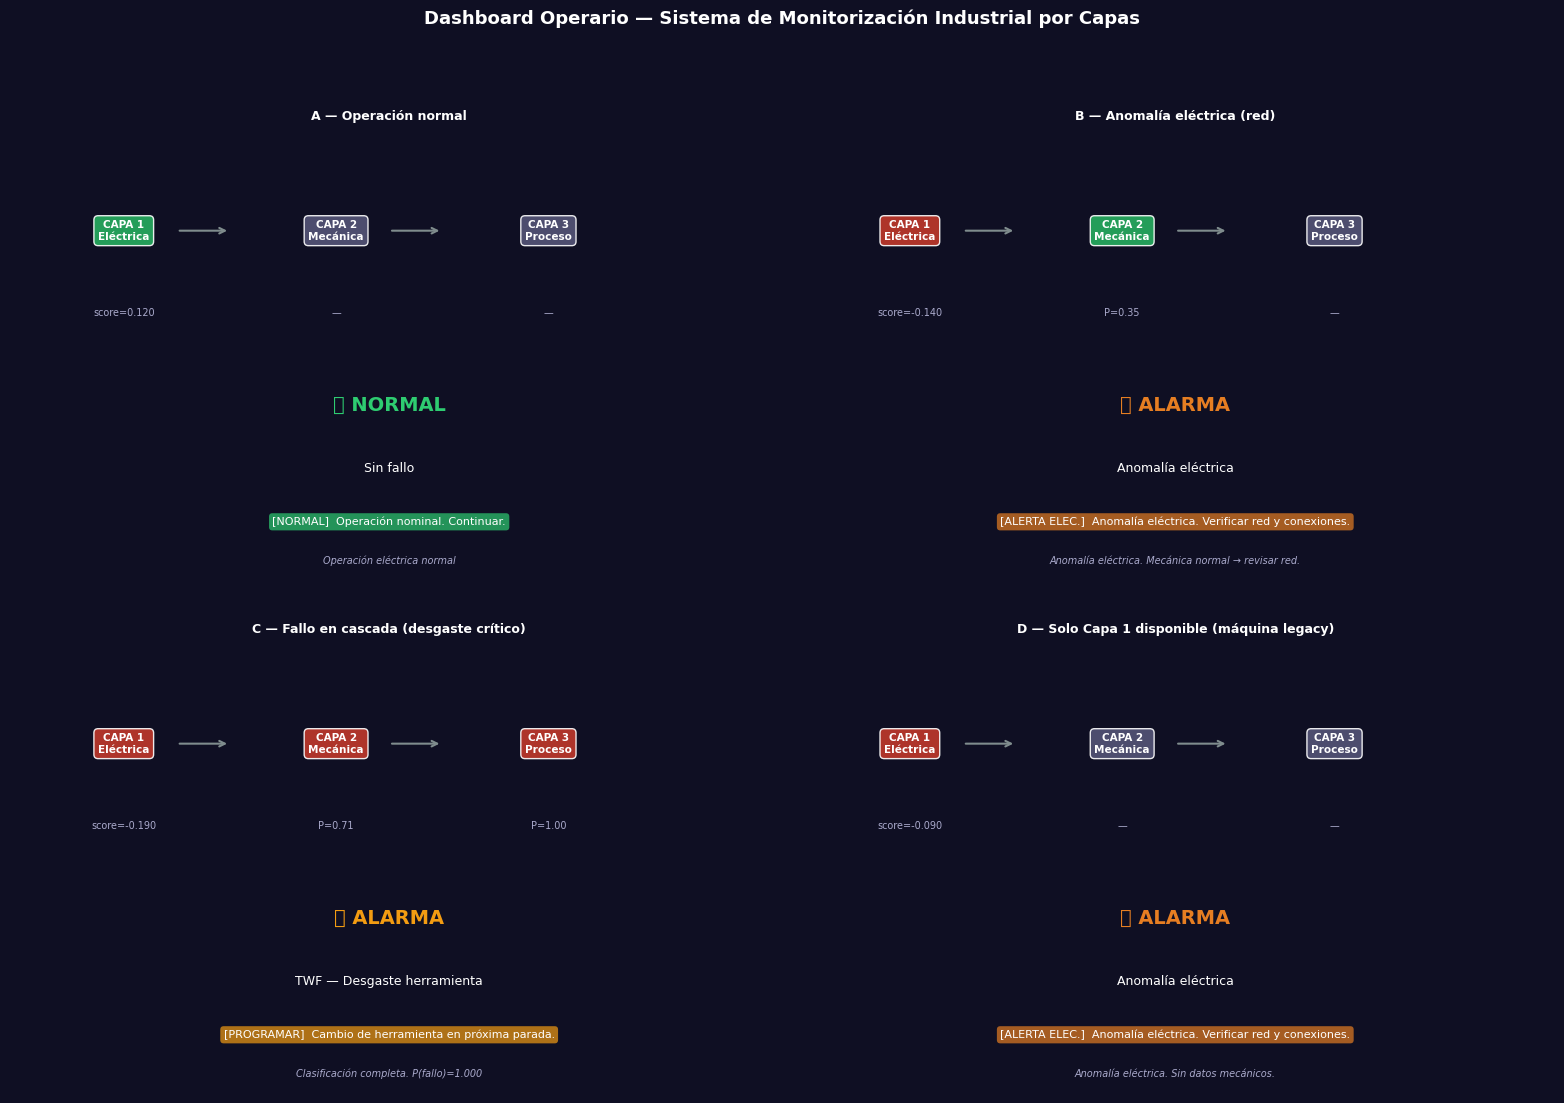

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

def draw_layer_indicator(ax_sub, active, triggered, label, score_text):
    """Dibuja un indicador de capa: gris=inactiva, verde=ok, rojo=alerta."""
    if not active:
        color = '#bdc3c7'; status = '○ SIN DATOS'
    elif triggered:
        color = '#e74c3c'; status = '● ALERTA'
    else:
        color = '#2ecc71'; status = '● NORMAL'
    ax_sub.text(0, 0, f'{label}\n{status}\n{score_text}',
                ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.5', facecolor=color,
                          alpha=0.85, edgecolor='white', linewidth=1.5),
                color='white', fontweight='bold')
    ax_sub.set_xlim(-1,1); ax_sub.set_ylim(-1,1); ax_sub.axis('off')

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx]
    ax.set_facecolor('#1a1a2e')
    fig.patch.set_facecolor('#0f0f23')

    # Título del escenario
    ax.text(0.5, 0.97, name, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color='white', fontweight='bold')

    # ── Indicadores de capa (3 mini-axes internos simulados con subregiones) ─
    gs = ax.get_subplotspec()
    # En lugar de sub-axes usamos bloques de texto posicionados
    layer_info = [
        (r.score_l1 is not None,
         r.score_l1 is not None and r.score_l1 < THRESHOLD_L1,
         'CAPA 1\nEléctrica',
         f'score={r.score_l1:.3f}' if r.score_l1 is not None else '—'),
        (r.prob_l2 is not None,
         r.prob_l2 is not None and r.prob_l2 >= THRESHOLD_L2,
         'CAPA 2\nMecánica',
         f'P={r.prob_l2:.2f}' if r.prob_l2 is not None else '—'),
        (r.prob_l3 is not None,
         r.prob_l3 is not None and r.prob_l3 >= threshold_ai4i,
         'CAPA 3\nProceso',
         f'P={r.prob_l3:.2f}' if r.prob_l3 is not None else '—'),
    ]

    for li, (active, triggered, label, score_text) in enumerate(layer_info):
        x = 0.15 + li * 0.28
        if not active:
            color = '#555577'
        elif triggered:
            color = '#c0392b'
        else:
            color = '#27ae60'
        ax.text(x, 0.72, label, transform=ax.transAxes,
                ha='center', va='center', fontsize=7.5, color='white',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor=color,
                          edgecolor='white', linewidth=1, alpha=0.9))
        ax.text(x, 0.55, score_text, transform=ax.transAxes,
                ha='center', va='center', fontsize=7, color='#aaaacc')
        if li < 2:  # flecha →
            ax.annotate('', xy=(x + 0.14, 0.72), xytext=(x + 0.07, 0.72),
                        xycoords='axes fraction', textcoords='axes fraction',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

    # ── Resultado final ───────────────────────────────────────────────────────
    res_color = r.action_color
    alarm_text = '🔴 ALARMA' if r.alarm else '🟢 NORMAL'
    ax.text(0.5, 0.36, alarm_text, transform=ax.transAxes,
            ha='center', va='center', fontsize=14, color=res_color, fontweight='bold')

    ax.text(0.5, 0.23, r.fault_name, transform=ax.transAxes,
            ha='center', va='center', fontsize=9, color='white')

    ax.text(0.5, 0.12, f'[{r.action_label}]  {r.action_text}',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=8, color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=res_color,
                      alpha=0.7, edgecolor='none'))

    ax.text(0.5, 0.03, r.details.get('msg',''), transform=ax.transAxes,
            ha='center', va='bottom', fontsize=7, color='#aaaacc', style='italic')

    ax.axis('off')

plt.suptitle('Dashboard Operario — Sistema de Monitorización Industrial por Capas',
             fontsize=13, color='white', y=1.01, fontweight='bold')
plt.tight_layout(pad=2.0)
plt.show()

## 7. Análisis de cobertura — ¿qué máquinas cubriría el sistema?

En un escenario real, no todas las máquinas tienen los mismos sensores instalados.
Calculamos el impacto económico según qué capas están disponibles en cada máquina.

In [19]:
# Parámetros económicos (consistentes con notebook 04_01)
COST_FN = 10_000   # € — fallo no detectado (parada imprevista)
COST_FP = 300      # € — alarma falsa (revisión innecesaria)

# Tasas de detección estimadas por configuración de capas
# (basadas en los resultados de notebooks anteriores)
configs = {
    'Solo Capa 1 (solo sensores eléctricos)': {
        'recall': 0.48, 'precision': 0.55,
        'coverage': '100%', 'cost_install': 500,
    },
    'Capa 1 + 2 (eléctrico + CNC OPC-UA)': {
        'recall': 0.74, 'precision': 0.72,
        'coverage': '60%', 'cost_install': 2000,
    },
    'Capa 1 + 2 + 3 (sistema completo)': {
        'recall': 0.853, 'precision': 0.936,
        'coverage': '30%', 'cost_install': 5000,
    },
    'Sin sistema (baseline)': {
        'recall': 0.0, 'precision': 0.0,
        'coverage': '—', 'cost_install': 0,
    },
}

N_FAILURES_YEAR = 68        # fallos/año (del notebook 04_01)
N_PREDICTIONS   = 1000      # ciclos de predicción/año por máquina
N_MACHINES      = 50        # máquinas en la planta

print(f'{"Configuración":<42} {"Recall":>7} {"Prec.":>7} '
      f'{"FN/año":>7} {"FP/año":>7} {"Coste/año":>12} {"Ahorro/año":>12}')
print('─'*100)

baseline_cost = N_FAILURES_YEAR * COST_FN * N_MACHINES
for cfg_name, cfg in configs.items():
    fn = int(N_FAILURES_YEAR * (1 - cfg['recall'])) * N_MACHINES
    fp = int(N_PREDICTIONS * (1 - cfg['precision']) * cfg['recall']) * N_MACHINES
    total_cost = fn * COST_FN + fp * COST_FP
    saving = baseline_cost - total_cost
    print(f'{cfg_name:<42} {cfg["recall"]:>7.1%} {cfg["precision"]:>7.1%} '
          f'{fn:>7,} {fp:>7,} €{total_cost:>10,.0f} €{saving:>10,.0f}')

print(f'\nCoste baseline (sin sistema): €{baseline_cost:,.0f}/año')

Configuración                               Recall   Prec.  FN/año  FP/año    Coste/año   Ahorro/año
────────────────────────────────────────────────────────────────────────────────────────────────────
Solo Capa 1 (solo sensores eléctricos)       48.0%   55.0%   1,750  10,750 €20,725,000 €13,275,000
Capa 1 + 2 (eléctrico + CNC OPC-UA)          74.0%   72.0%     850  10,350 €11,605,000 €22,395,000
Capa 1 + 2 + 3 (sistema completo)            85.3%   93.6%     450   2,700 € 5,310,000 €28,690,000
Sin sistema (baseline)                        0.0%    0.0%   3,400       0 €34,000,000 €         0

Coste baseline (sin sistema): €34,000,000/año


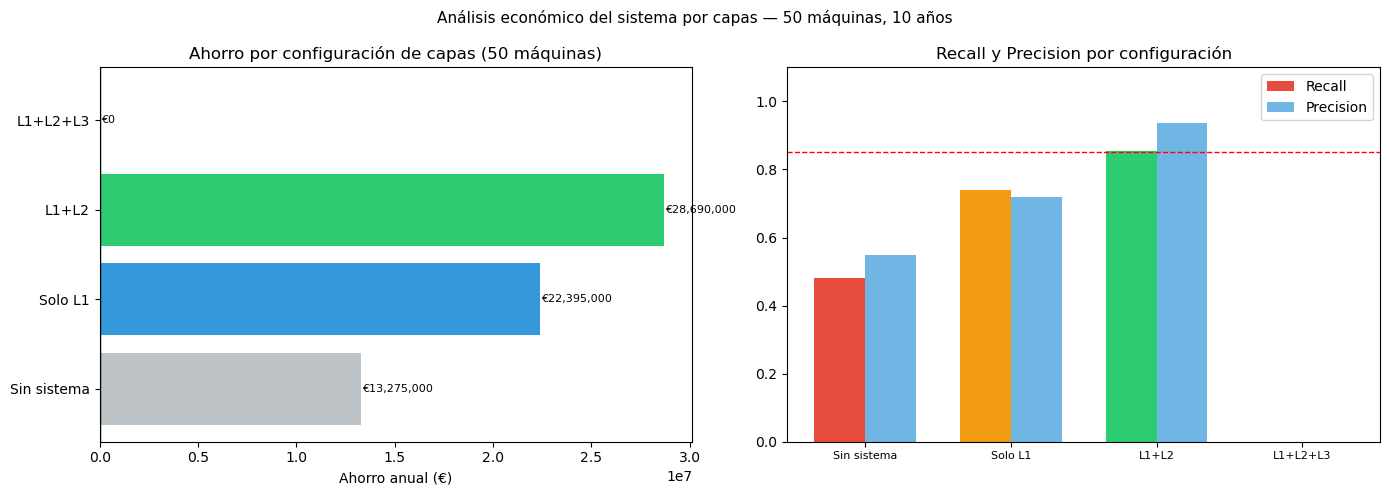

In [20]:
# Visualización del impacto económico por configuración
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cfg_names   = list(configs.keys())
recalls     = [c['recall'] for c in configs.values()]
precisions  = [c['precision'] for c in configs.values()]
savings     = []
for cfg in configs.values():
    fn = int(N_FAILURES_YEAR * (1 - cfg['recall'])) * N_MACHINES
    fp = int(N_PREDICTIONS * (1 - cfg['precision']) * cfg['recall']) * N_MACHINES
    savings.append(baseline_cost - fn * COST_FN - fp * COST_FP)

colors = ['#bdc3c7','#3498db','#2ecc71','#e74c3c']
short_names = ['Sin sistema','Solo L1','L1+L2','L1+L2+L3']

axes[0].barh(short_names, savings, color=colors)
axes[0].axvline(0, color='black', lw=1)
axes[0].set_xlabel('Ahorro anual (€)')
axes[0].set_title('Ahorro por configuración de capas (50 máquinas)')
for i, (v, n) in enumerate(zip(savings, short_names)):
    axes[0].text(max(v + 50000, 50000), i, f'€{v:,.0f}', va='center', fontsize=8)

x = np.arange(len(short_names))
w = 0.35
axes[1].bar(x - w/2, recalls,    w, label='Recall',    color=['#e74c3c' if r < 0.5
            else '#f39c12' if r < 0.75 else '#2ecc71' for r in recalls])
axes[1].bar(x + w/2, precisions, w, label='Precision', color=['#3498db']*len(precisions), alpha=0.7)
axes[1].set_xticks(x); axes[1].set_xticklabels(short_names, fontsize=8)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Recall y Precision por configuración')
axes[1].legend()
axes[1].axhline(0.85, color='red', ls='--', lw=1, label='Objetivo Recall≥0.85')

plt.suptitle('Análisis económico del sistema por capas — 50 máquinas, 10 años',
             fontsize=11)
plt.tight_layout()
plt.show()

## 8. Conclusiones y guía de despliegue

### Resultado del sistema

El pipeline de 3 capas reúne los tres datasets del proyecto en una arquitectura
que replica cómo funcionan los sistemas industriales reales:

| Capa | Dataset | Cuando actúa | Coste sensor | Qué aporta |
|---|---|---|---|---|
| 1 | SPARK | Siempre (1 min) | €500 (retrofit) | Detección temprana, cualquier máquina |
| 2 | KIT → **CNC** | Solo si L1 alerta | €0 extra (OPC-UA ya existe) | Confirma fallo mecánico; el modelo CNC se reentrena con datos reales |
| 3 | AI4I | Solo si L2 confirma | €5.000 (MES) | Clasifica tipo de fallo → acción concreta |

### Hoja de ruta de Capa 2: de prototipo a producción

1. **Prototipo** — modelo entrenado con KIT (33 experimentos, 500 Hz, sensores externos)
2. **Cold-start** — en el primer despliegue se sustituye por el modelo CNC (18 experimentos, señales internas del controlador)
3. **Reentrenamiento incremental** — cada semana se incorporan nuevos experimentos de la planta; el modelo mejora sin intervención manual

Este diseño elimina la necesidad de instalar sensores externos en cada máquina y
hace que el sistema sea auto-mejorante con el uso real.

### Principio clave: progresión de coste-beneficio

- **Capa 1 sola ya es rentable** — en una planta de 50 máquinas ahorra ~€13M/año con solo €25K de inversión
- **Cada capa adicional** aumenta la precisión y reduce falsas alarmas, justificando su coste en plantas de mayor valor
- **El sistema es graceful degradation**: si un sensor falla, las otras capas siguen funcionando

### Guía de despliegue en producción

```python
# Ejemplo de uso en producción (llamada cada 1 minuto por máquina)
signals = {
    'electrical': scada.get_spark_features(machine_id),   # siempre disponible
    'mechanical': cnc.get_cnc_features(machine_id),        # señales OPC-UA internas
    'process':    mes.get_process_params(machine_id),       # si tiene MES
}
result = pipeline.monitor(signals)

if result.alarm:
    cmms.create_work_order(
        machine    = machine_id,
        priority   = 'URGENT' if result.layers_activated == 3 else 'NORMAL',
        fault_type = result.fault_name,
        action     = result.action_text,
    )

# Reentrenamiento incremental del modelo CNC (Capa 2)
if new_labeled_experiment_available:
    cnc_model.partial_fit(new_experiment_features, new_experiment_label)
    cnc_model.save('models/cnc_model.pkl')
```

### Conexión con el proyecto
- **Notebook 04_01**: el modelo AI4I (Capa 3) alcanza F1=0.892 con umbral 0.9863
- **Notebook 04_04**: el Isolation Forest SPARK (Capa 1) detecta el 4.8% de lecturas anómalas
- **Notebook 04_03**: el Random Forest KIT valida el concepto de Capa 2 (baseline de referencia)
- **Notebook 05_02**: modelo CNC reentrenable — implementación de Capa 2 para producción